# CIFAR-10 Final Assessment Notebook



In [ ]:
import csv
import json
import math
import os
import random
import shutil
import subprocess
import sys
import time
from collections import OrderedDict
from datetime import datetime
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "py7zr"],
        check=True,
    )
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import confusion_matrix
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.models import ResNet50_Weights, resnet50
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm
from IPython.display import display


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

def resolve_data_root(project_root):
    candidate_roots = [
        project_root,
        project_root / "cifar-10",
    ]
    required_names = ["train.7z", "trainLabels.csv"]

    for candidate in candidate_roots:
        if all((candidate / name).exists() for name in required_names):
            return candidate

    return candidate_roots[0]


SOURCE_DATA_ROOT = resolve_data_root(PROJECT_ROOT)
WORKING_DATA_ROOT = Path("/content/cifar10_working") if IN_COLAB else SOURCE_DATA_ROOT
TRAIN_ARCHIVE_PATH = SOURCE_DATA_ROOT / "train.7z"
TRAIN_LABELS_PATH = SOURCE_DATA_ROOT / "trainLabels.csv"
TRAIN_IMAGES_DIR = WORKING_DATA_ROOT / "train"

NOTEBOOK_OUTPUT_ROOT = PROJECT_ROOT / "Outputs" / "final_assessment_notebook"
NOTEBOOK_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

SCRATCH_TAKE4_ARCHIVE_SUMMARY_PATH = (
    PROJECT_ROOT / "Data" / "improved_cnn_outputs" / "cnn_take_4_20260326_234323" / "summary.json"
)
TRANSFER_RESNET18_ARCHIVE_SUMMARY_PATH = (
    PROJECT_ROOT / "Data" / "transfer_learning_outputs" / "run_20260329_030438" / "summary.json"
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"

if DEVICE.type == "cuda":
    torch.backends.cudnn.benchmark = True

required_files = [TRAIN_ARCHIVE_PATH, TRAIN_LABELS_PATH]
missing_files = [str(path) for path in required_files if not path.exists()]
if missing_files:
    raise FileNotFoundError(
        "The following required files were not found:\n" + "\n".join(missing_files)
    )

print("IN_COLAB:", IN_COLAB)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SOURCE_DATA_ROOT:", SOURCE_DATA_ROOT)
print("WORKING_DATA_ROOT:", WORKING_DATA_ROOT)
print("TRAIN_IMAGES_DIR:", TRAIN_IMAGES_DIR)
print("NOTEBOOK_OUTPUT_ROOT:", NOTEBOOK_OUTPUT_ROOT)
print("DEVICE:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Warning: GPU not detected. Full training will be very slow on CPU.")

pd.DataFrame(
    {
        "path": [str(path) for path in required_files],
        "exists": [path.exists() for path in required_files],
        "size_mb": [round(path.stat().st_size / (1024 * 1024), 2) for path in required_files],
    }
)

IN_COLAB: True
PROJECT_ROOT: /content/drive/MyDrive
SOURCE_DATA_ROOT: /content/drive/MyDrive
WORKING_DATA_ROOT: /content/cifar10_working
TRAIN_IMAGES_DIR: /content/cifar10_working/train
NOTEBOOK_OUTPUT_ROOT: /content/drive/MyDrive/Outputs/final_assessment_notebook
DEVICE: cuda
GPU: Tesla T4


,path,exists,size_mb
0,/content/drive/MyDrive/train.7z,True,104.64
1,/content/drive/MyDrive/trainLabels.csv,True,0.56


In [ ]:
CIFAR10_CLASSES = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
CLASS_TO_INDEX = {label: index for index, label in enumerate(CIFAR10_CLASSES)}
EXPECTED_TRAIN_IMAGE_COUNT = 50000
SEED = 42
VALIDATION_SPLIT = 0.1
TEST_SPLIT = 0.1

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


def ensure_py7zr_available():
    try:
        import py7zr
    except ImportError as exc:
        raise ImportError("py7zr is required. Install it with pip install py7zr.") from exc
    return py7zr


def ensure_train_images_extracted():
    existing_count = len(list(TRAIN_IMAGES_DIR.glob("*.png"))) if TRAIN_IMAGES_DIR.exists() else 0
    if existing_count >= EXPECTED_TRAIN_IMAGE_COUNT:
        return TRAIN_IMAGES_DIR

    py7zr = ensure_py7zr_available()
    if TRAIN_IMAGES_DIR.exists():
        shutil.rmtree(TRAIN_IMAGES_DIR)
    TRAIN_IMAGES_DIR.parent.mkdir(parents=True, exist_ok=True)

    with py7zr.SevenZipFile(TRAIN_ARCHIVE_PATH, mode="r") as archive:
        archive.extractall(path=TRAIN_IMAGES_DIR.parent)

    return TRAIN_IMAGES_DIR


def load_labels():
    rows = []
    with TRAIN_LABELS_PATH.open("r", encoding="utf-8", newline="") as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            rows.append({"id": row["id"], "label": row["label"]})
    return pd.DataFrame(rows)


def build_labeled_samples():
    extracted_train_dir = ensure_train_images_extracted()
    labels_df = load_labels()
    samples = []
    for row in labels_df.itertuples(index=False):
        image_path = extracted_train_dir / f"{row.id}.png"
        samples.append((image_path, CLASS_TO_INDEX[row.label], row.label))
    return samples, labels_df


class CIFAR10Dataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples = samples
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        image_path, target, label_name = self.samples[index]
        with Image.open(image_path) as image:
            image = image.convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        return image, target


def split_indices(dataset_size, validation_split=VALIDATION_SPLIT, test_split=TEST_SPLIT, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    indices = torch.randperm(dataset_size, generator=generator).tolist()

    val_size = int(dataset_size * validation_split)
    test_size = int(dataset_size * test_split)
    train_size = dataset_size - val_size - test_size

    train_indices = indices[:train_size]
    val_indices = indices[train_size : train_size + val_size]
    test_indices = indices[train_size + val_size :]
    return train_indices, val_indices, test_indices


def subset_samples(samples, indices):
    return [samples[index] for index in indices]


def get_dataloader(dataset, batch_size=64, shuffle=False, num_workers=0):
    loader_kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": num_workers,
        "pin_memory": DEVICE.type == "cuda",
    }
    if num_workers > 0:
        loader_kwargs["persistent_workers"] = True
    return DataLoader(dataset, **loader_kwargs)


ALL_SAMPLES, LABELS_DF = build_labeled_samples()
TRAIN_INDICES, VAL_INDICES, TEST_INDICES = split_indices(len(ALL_SAMPLES))
TRAIN_SAMPLES = subset_samples(ALL_SAMPLES, TRAIN_INDICES)
VAL_SAMPLES = subset_samples(ALL_SAMPLES, VAL_INDICES)
TEST_SAMPLES = subset_samples(ALL_SAMPLES, TEST_INDICES)

print("Total labeled samples:", len(ALL_SAMPLES))
print("Train samples:", len(TRAIN_SAMPLES))
print("Validation samples:", len(VAL_SAMPLES))
print("Test samples:", len(TEST_SAMPLES))


Total labeled samples: 50000
Train samples: 40000
Validation samples: 5000
Test samples: 5000


## Exploratory Data Analysis



In [ ]:
class_count_df = (
    LABELS_DF["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
    .sort_values("label")
    .reset_index(drop=True)
)
class_count_df


,label,count
0,airplane,5000
1,automobile,5000
2,bird,5000
3,cat,5000
4,deer,5000
5,dog,5000
6,frog,5000
7,horse,5000
8,ship,5000
9,truck,5000


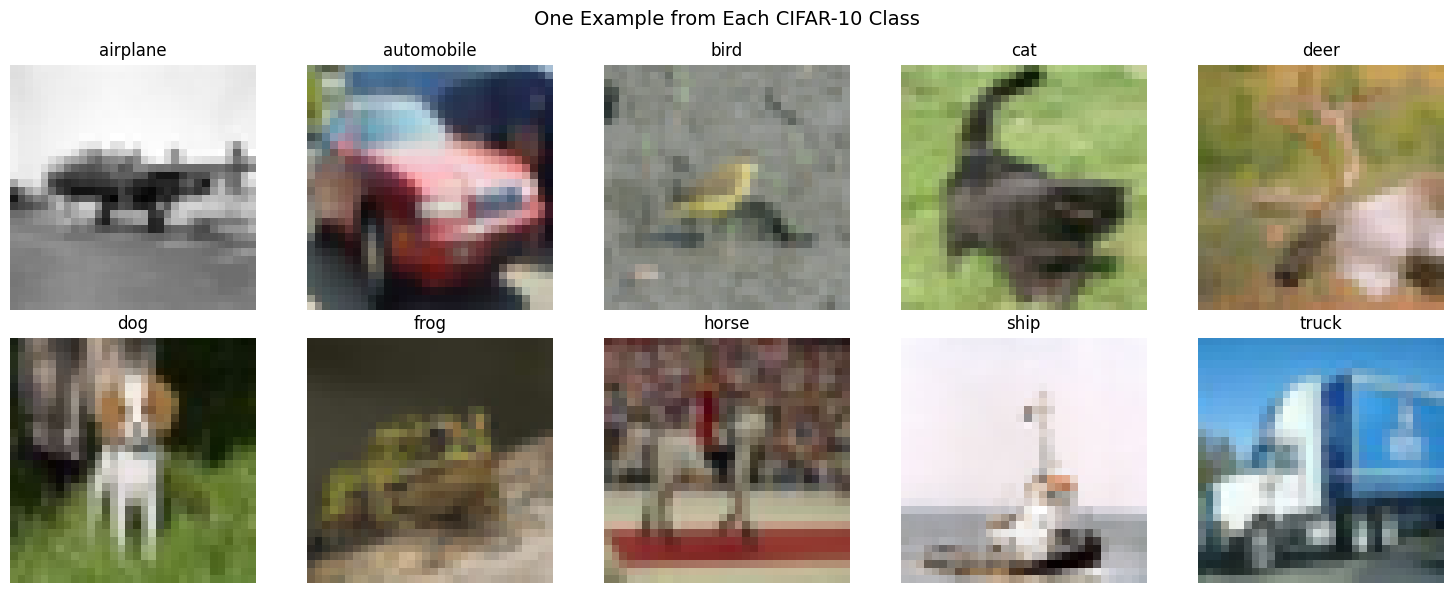

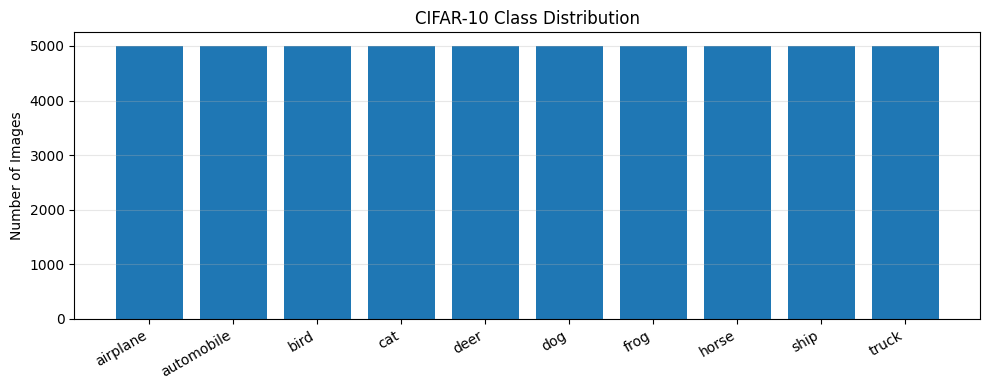

In [ ]:
random.seed(SEED)
sample_per_class = []
for class_name in CIFAR10_CLASSES:
    class_rows = LABELS_DF[LABELS_DF["label"] == class_name]
    row = class_rows.sample(n=1, random_state=SEED).iloc[0]
    sample_per_class.append((class_name, TRAIN_IMAGES_DIR / f"{row['id']}.png"))

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for axis, (class_name, image_path) in zip(axes.flatten(), sample_per_class):
    with Image.open(image_path) as image:
        axis.imshow(image)
    axis.set_title(class_name)
    axis.axis("off")
plt.suptitle("One Example from Each CIFAR-10 Class", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(class_count_df["label"], class_count_df["count"], color="tab:blue")
plt.title("CIFAR-10 Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Pre-processing and Data Loading


The notebook uses two different pre-processing pipelines:

- a native `32x32` pipeline for the scratch CNN
- an ImageNet-style `224x224` pipeline for `ResNet50`


In [ ]:
def build_cnn_train_transform():
    return transforms.Compose(
        [
            transforms.RandomCrop(32, padding=4, padding_mode="reflect"),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomAffine(
                degrees=4.0,
                translate=(0.05, 0.05),
                scale=(0.95, 1.05),
                shear=2.0,
            ),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.02,
            ),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
            transforms.RandomErasing(
                p=0.1,
                scale=(0.02, 0.2),
                ratio=(0.3, 3.3),
                value="random",
            ),
        ]
    )


def build_cnn_eval_transform():
    return transforms.Compose(
        [
            transforms.ToTensor(),
            transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD),
        ]
    )


def build_transfer_train_transform():
    return transforms.Compose(
        [
            transforms.RandomResizedCrop(
                224,
                scale=(0.7, 1.0),
                interpolation=InterpolationMode.BILINEAR,
            ),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ColorJitter(
                brightness=0.2,
                contrast=0.2,
                saturation=0.2,
                hue=0.02,
            ),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(
                p=0.1,
                scale=(0.02, 0.15),
                ratio=(0.3, 3.3),
                value="random",
            ),
        ]
    )


def build_transfer_eval_transform():
    return transforms.Compose(
        [
            transforms.Resize(232, interpolation=InterpolationMode.BILINEAR),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]
    )


def build_dataloaders(train_samples, val_samples, test_samples, train_transform, eval_transform, batch_size, num_workers):
    train_dataset = CIFAR10Dataset(train_samples, transform=train_transform)
    val_dataset = CIFAR10Dataset(val_samples, transform=eval_transform)
    test_dataset = CIFAR10Dataset(test_samples, transform=eval_transform)
    train_dataloader = get_dataloader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_dataloader = get_dataloader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    test_dataloader = get_dataloader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    return train_dataloader, val_dataloader, test_dataloader


## Model Design Choices: CNN Take 4


In [ ]:
def make_downsample(channels, pooling_type):
    if pooling_type == "max":
        return nn.MaxPool2d(kernel_size=2, stride=2)
    if pooling_type == "avg":
        return nn.AvgPool2d(kernel_size=2, stride=2)
    if pooling_type == "stride":
        return nn.Conv2d(
            in_channels=channels,
            out_channels=channels,
            kernel_size=3,
            stride=2,
            padding=1,
            bias=False,
        )
    raise ValueError("pooling_type must be one of: 'max', 'avg', or 'stride'.")


class ConvBNReLU(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                stride=stride,
                padding=padding,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
        )

    def forward(self, x):
        return self.block(x)


class DeeperCIFAR10CNN(nn.Module):
    def __init__(
        self,
        num_classes=10,
        channels=(48, 96, 192, 256),
        blocks_per_stage=(2, 2, 1, 1),
        pooling_type="stride",
        dropout=0.15,
        classifier_hidden=256,
    ):
        super().__init__()

        stages = []
        in_channels = 3
        for stage_index, (stage_channels, num_blocks) in enumerate(
            zip(channels, blocks_per_stage), start=1
        ):
            layers = []
            for _ in range(num_blocks):
                layers.append(ConvBNReLU(in_channels=in_channels, out_channels=stage_channels))
                in_channels = stage_channels
            if stage_index < len(channels):
                layers.append(make_downsample(stage_channels, pooling_type))
            stages.append((f"stage{stage_index}", nn.Sequential(*layers)))

        self.features = nn.Sequential(OrderedDict(stages))
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(channels[-1], classifier_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        x = self.classifier(x)
        return x

    @torch.no_grad()
    def describe_feature_shapes(self, input_shape=(1, 3, 32, 32)):
        x = torch.zeros(input_shape)
        shapes = {"input": tuple(x.shape)}
        for name, module in self.features.named_children():
            x = module(x)
            shapes[name] = tuple(x.shape)
        x = self.global_pool(x)
        shapes["global_pool"] = tuple(x.shape)
        x = self.classifier(x)
        shapes["logits"] = tuple(x.shape)
        return shapes


cnn_take4_preview = DeeperCIFAR10CNN()
print(cnn_take4_preview)
print("Feature map shapes:", cnn_take4_preview.describe_feature_shapes())


DeeperCIFAR10CNN(
  (features): Sequential(
    (stage1): Sequential(
      (0): ConvBNReLU(
        (block): Sequential(
          (0): Conv2d(3, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
      )
      (1): ConvBNReLU(
        (block): Sequential(
          (0): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU()
        )
      )
      (2): Conv2d(48, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    )
    (stage2): Sequential(
      (0): ConvBNReLU(
        (block): Sequential(
          (0): Conv2d(48, 96, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          

## Training Strategy and Hyperparameter Tuning


In [ ]:
class ClassificationLoss(nn.Module):
    def __init__(self, num_classes, label_smoothing=0.0):
        super().__init__()
        self.num_classes = num_classes
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        if targets.ndim == 1:
            return F.cross_entropy(logits, targets, label_smoothing=self.label_smoothing)

        smoothed_targets = targets
        if self.label_smoothing > 0.0:
            smoothed_targets = (
                smoothed_targets * (1.0 - self.label_smoothing)
                + self.label_smoothing / self.num_classes
            )

        log_probs = F.log_softmax(logits, dim=1)
        return -(smoothed_targets * log_probs).sum(dim=1).mean()


def one_hot(labels, num_classes):
    return torch.zeros(labels.size(0), num_classes, device=labels.device).scatter_(1, labels.unsqueeze(1), 1.0)


def apply_mixup(images, labels, alpha, num_classes):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1.0 - lam) * images[index]
    labels_one_hot = one_hot(labels, num_classes)
    mixed_labels = lam * labels_one_hot + (1.0 - lam) * labels_one_hot[index]
    return mixed_images, mixed_labels


def apply_cutmix(images, labels, alpha, num_classes):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    batch_size, _, height, width = images.shape
    index = torch.randperm(batch_size, device=images.device)
    cut_ratio = math.sqrt(1.0 - lam)
    cut_width = int(width * cut_ratio)
    cut_height = int(height * cut_ratio)

    cx = np.random.randint(width)
    cy = np.random.randint(height)

    x1 = np.clip(cx - cut_width // 2, 0, width)
    x2 = np.clip(cx + cut_width // 2, 0, width)
    y1 = np.clip(cy - cut_height // 2, 0, height)
    y2 = np.clip(cy + cut_height // 2, 0, height)

    mixed_images = images.clone()
    mixed_images[:, :, y1:y2, x1:x2] = images[index, :, y1:y2, x1:x2]

    lam_adjusted = 1.0 - ((x2 - x1) * (y2 - y1) / (width * height))
    labels_one_hot = one_hot(labels, num_classes)
    mixed_labels = lam_adjusted * labels_one_hot + (1.0 - lam_adjusted) * labels_one_hot[index]
    return mixed_images, mixed_labels


def build_batch_mixer(num_classes, mixup_alpha=0.0, cutmix_alpha=0.0):
    def batch_mixer(images, labels):
        if mixup_alpha > 0.0 and cutmix_alpha > 0.0:
            if random.random() < 0.5:
                return apply_mixup(images, labels, mixup_alpha, num_classes)
            return apply_cutmix(images, labels, cutmix_alpha, num_classes)
        if mixup_alpha > 0.0:
            return apply_mixup(images, labels, mixup_alpha, num_classes)
        if cutmix_alpha > 0.0:
            return apply_cutmix(images, labels, cutmix_alpha, num_classes)
        return images, labels

    if mixup_alpha <= 0.0 and cutmix_alpha <= 0.0:
        return None
    return batch_mixer


def build_warmup_cosine_scheduler(optimizer, epochs, warmup_epochs, min_learning_rate):
    if epochs <= 1:
        return torch.optim.lr_scheduler.ConstantLR(optimizer, factor=1.0, total_iters=1)

    effective_warmup_epochs = min(warmup_epochs, max(epochs - 1, 0))
    cosine_epochs = max(epochs - effective_warmup_epochs, 1)

    cosine_scheduler = CosineAnnealingLR(
        optimizer,
        T_max=cosine_epochs,
        eta_min=min_learning_rate,
    )

    if effective_warmup_epochs <= 0:
        return cosine_scheduler

    warmup_scheduler = LinearLR(
        optimizer,
        start_factor=0.1,
        end_factor=1.0,
        total_iters=effective_warmup_epochs,
    )

    return SequentialLR(
        optimizer,
        schedulers=[warmup_scheduler, cosine_scheduler],
        milestones=[effective_warmup_epochs],
    )


def create_run_dir(run_label):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    run_dir = NOTEBOOK_OUTPUT_ROOT / f"{run_label}_{timestamp}"
    run_dir.mkdir(parents=True, exist_ok=True)
    return run_dir


def run_epoch(
    model,
    dataloader,
    criterion,
    optimizer=None,
    scaler=None,
    batch_mixer=None,
    grad_clip_norm=None,
    max_batches=None,
    desc="",
):
    training = optimizer is not None
    model.train(training)

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    progress_bar = tqdm(dataloader, desc=desc, leave=False)

    for batch_index, (images, labels) in enumerate(progress_bar, start=1):
        if max_batches is not None and batch_index > max_batches:
            break

        images = images.to(DEVICE, non_blocking=DEVICE.type == "cuda")
        labels = labels.to(DEVICE, non_blocking=DEVICE.type == "cuda")
        metric_labels = labels

        if training and optimizer is not None:
            optimizer.zero_grad(set_to_none=True)

        loss_targets = labels
        if training and batch_mixer is not None:
            images, loss_targets = batch_mixer(images, labels)

        with torch.amp.autocast("cuda", enabled=USE_AMP):
            logits = model(images)
            loss = criterion(logits, loss_targets)

        if training and optimizer is not None:
            scaler.scale(loss).backward()
            if grad_clip_norm is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            scaler.step(optimizer)
            scaler.update()

        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * metric_labels.size(0)
        total_correct += (predictions == metric_labels).sum().item()
        total_examples += metric_labels.size(0)

        progress_bar.set_postfix(
            loss=f"{total_loss / max(total_examples, 1):.4f}",
            acc=f"{total_correct / max(total_examples, 1):.4f}",
        )

    return {
        "loss": total_loss / max(total_examples, 1),
        "accuracy": total_correct / max(total_examples, 1),
    }


@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    all_targets = []
    all_predictions = []
    for images, labels in dataloader:
        images = images.to(DEVICE, non_blocking=DEVICE.type == "cuda")
        logits = model(images)
        predictions = logits.argmax(dim=1).cpu().numpy()
        all_predictions.extend(predictions.tolist())
        all_targets.extend(labels.numpy().tolist())
    return np.array(all_targets), np.array(all_predictions)



## CNN Take 4: Training Strategy and Model Run



In [ ]:
CNN_TAKE4_CONFIG = {
    "run_label": "final_notebook_cnn_take4",
    "epochs": 15,
    "batch_size": 256,
    "num_workers": 2 if DEVICE.type == "cuda" else 0,
    "learning_rate": 5e-4,
    "min_learning_rate": 1e-5,
    "weight_decay": 5e-4,
    "dropout": 0.15,
    "label_smoothing": 0.1,
    "warmup_epochs": 1,
    "grad_clip_norm": None,
    "mixup_alpha": 0.2,
    "cutmix_alpha": 1.0,
    "limit_train_batches": None,
    "limit_val_batches": None,
    "limit_test_batches": None,
}


def train_cnn_take4(config):
    set_seed(SEED)
    run_dir = create_run_dir(config["run_label"])

    train_dataloader, val_dataloader, test_dataloader = build_dataloaders(
        TRAIN_SAMPLES,
        VAL_SAMPLES,
        TEST_SAMPLES,
        build_cnn_train_transform(),
        build_cnn_eval_transform(),
        batch_size=config["batch_size"],
        num_workers=config["num_workers"],
    )

    model = DeeperCIFAR10CNN(
        num_classes=len(CIFAR10_CLASSES),
        channels=(48, 96, 192, 256),
        blocks_per_stage=(2, 2, 1, 1),
        pooling_type="stride",
        dropout=config["dropout"],
        classifier_hidden=256,
    ).to(DEVICE)

    criterion = ClassificationLoss(
        num_classes=len(CIFAR10_CLASSES),
        label_smoothing=config["label_smoothing"],
    )
    optimizer = AdamW(
        model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )
    scheduler = build_warmup_cosine_scheduler(
        optimizer,
        epochs=config["epochs"],
        warmup_epochs=config["warmup_epochs"],
        min_learning_rate=config["min_learning_rate"],
    )
    batch_mixer = build_batch_mixer(
        num_classes=len(CIFAR10_CLASSES),
        mixup_alpha=config["mixup_alpha"],
        cutmix_alpha=config["cutmix_alpha"],
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = []
    best_val_accuracy = 0.0
    best_weights_path = run_dir / "best_cnn_take4.pt"
    epoch_times = []

    print("Starting CNN Take 4 training...")
    print("Run directory:", run_dir)
    print("Epochs:", config["epochs"])
    print("Batch size:", config["batch_size"])
    print("Device:", DEVICE)

    for epoch in range(1, config["epochs"] + 1):
        epoch_start = time.time()

        train_metrics = run_epoch(
            model=model,
            dataloader=train_dataloader,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            batch_mixer=batch_mixer,
            grad_clip_norm=config["grad_clip_norm"],
            max_batches=config["limit_train_batches"],
            desc=f"CNN Take 4 Train {epoch}/{config['epochs']}",
        )

        val_metrics = run_epoch(
            model=model,
            dataloader=val_dataloader,
            criterion=criterion,
            max_batches=config["limit_val_batches"],
            desc=f"CNN Take 4 Val {epoch}/{config['epochs']}",
        )

        scheduler.step()

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "learning_rate": optimizer.param_groups[0]["lr"],
            }
        )

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)
        avg_epoch_time = sum(epoch_times) / len(epoch_times)
        remaining_epochs = config["epochs"] - epoch
        eta_minutes = (avg_epoch_time * remaining_epochs) / 60.0

        print(
            f"Epoch {epoch:02d}/{config['epochs']} | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"time={epoch_time/60:.1f} min | ETA={eta_minutes:.1f} min"
        )

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            torch.save(model.state_dict(), best_weights_path)

    model.load_state_dict(torch.load(best_weights_path, map_location=DEVICE))
    test_metrics = run_epoch(
        model=model,
        dataloader=test_dataloader,
        criterion=criterion,
        max_batches=config["limit_test_batches"],
        desc="CNN Take 4 Test",
    )

    y_true, y_pred = predict_dataset(model, test_dataloader)
    confusion_matrix_path = run_dir / "cnn_take4_confusion_matrix.png"
    cm = save_confusion_matrix_plot(
        y_true,
        y_pred,
        CIFAR10_CLASSES,
        confusion_matrix_path,
        "CNN Take 4 Confusion Matrix",
    )

    history_df = pd.DataFrame(history)
    history_path = run_dir / "cnn_take4_history.csv"
    history_df.to_csv(history_path, index=False)
    curves_path = run_dir / "cnn_take4_training_curves.png"
    save_history_plot(history_df, curves_path, "CNN Take 4")

    summary = {
        "model": "cnn_take4",
        "run_dir": str(run_dir),
        "device": str(DEVICE),
        "epochs": config["epochs"],
        "batch_size": config["batch_size"],
        "learning_rate": config["learning_rate"],
        "min_learning_rate": config["min_learning_rate"],
        "weight_decay": config["weight_decay"],
        "dropout": config["dropout"],
        "label_smoothing": config["label_smoothing"],
        "warmup_epochs": config["warmup_epochs"],
        "mixup_alpha": config["mixup_alpha"],
        "cutmix_alpha": config["cutmix_alpha"],
        "best_val_accuracy": best_val_accuracy,
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "curves_path": str(curves_path),
        "confusion_matrix_path": str(confusion_matrix_path),
        "history_path": str(history_path),
        "history": history,
    }
    summary_path = run_dir / "cnn_take4_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    summary["summary_path"] = str(summary_path)


In [ ]:
RUN_CNN_TAKE4 = True

cnn_take4_summary = None
cnn_take4_history_df = None
cnn_take4_confusion_matrix = None

if RUN_CNN_TAKE4:
    print("Launching CNN Take 4 training cell...")
    cnn_take4_summary, cnn_take4_history_df, cnn_take4_confusion_matrix = train_cnn_take4(CNN_TAKE4_CONFIG)
    display(
        pd.Series(
            {
                "best_val_accuracy": round(cnn_take4_summary["best_val_accuracy"], 4),
                "test_accuracy": round(cnn_take4_summary["test_accuracy"], 4),
                "run_dir": cnn_take4_summary["run_dir"],
            }
        )
    )
    display(cnn_take4_history_df.tail())
else:
    print("CNN Take 4 training skipped.")


Launching CNN Take 4 training cell...
Starting CNN Take 4 training...
Run directory: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_cnn_take4_20260429_183907
Epochs: 15
Batch size: 256
Device: cuda


CNN Take 4 Train 1/15:   0%|          | 0/157 [00:00<?, ?it/s]

CNN Take 4 Val 1/15:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 01/15 | train_acc=0.2190 | val_acc=0.3798 | time=1.3 min | ETA=18.5 min


CNN Take 4 Train 2/15:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 15/15 | train_acc=0.5044 | val_acc=0.8140 | time=0.9 min | ETA=0.0 min


CNN Take 4 Test:   0%|          | 0/20 [00:00<?, ?it/s]

Finished CNN Take 4 training.
Best validation accuracy: 0.8166
Test accuracy: 0.8162


,0
best_val_accuracy,0.8166
test_accuracy,0.8162
run_dir,/content/drive/MyDrive/Outputs/final_assessmen...


,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
10,11,1.455196,0.469100,1.013762,0.7850,0.000102
11,12,1.484693,0.471175,0.967114,0.8036,0.000063
12,13,1.404068,0.477200,0.956713,0.8044,0.000034
13,14,1.453195,0.496325,0.940529,0.8166,0.000016
14,15,1.402642,0.504375,0.937879,0.8140,0.000010


## Model Design Choices: ResNet50



In [ ]:
RESNET50_WEIGHTS = ResNet50_Weights.DEFAULT


def build_resnet50_model(dropout=0.2):
    model = resnet50(weights=RESNET50_WEIGHTS)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, len(CIFAR10_CLASSES)),
    )
    return model


resnet50_preview = build_resnet50_model(dropout=0.2)
total_parameters = sum(parameter.numel() for parameter in resnet50_preview.parameters())
print("Classifier head:", resnet50_preview.fc)
print("Total parameters:", f"{total_parameters:,}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 130MB/s]


Classifier head: Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=2048, out_features=10, bias=True)
)
Total parameters: 23,528,522


In [ ]:
RESNET50_CONFIG = {
    "run_label": "final_notebook_resnet50",
    "batch_size": 32,
    "num_workers": 2 if DEVICE.type == "cuda" else 0,
    "total_epochs": 15,
    "head_only_epochs": 3,
    "head_only_lr": 1e-3,
    "full_head_lr": 3e-4,
    "full_backbone_lr": 1e-4,
    "weight_decay": 1e-4,
    "dropout": 0.2,
    "label_smoothing": 0.1,
    "grad_clip_norm": 1.0,
    "limit_train_batches": None,
    "limit_val_batches": None,
    "limit_test_batches": None,
}


def freeze_backbone(model):
    for name, parameter in model.named_parameters():
        parameter.requires_grad = name.startswith("fc.")


def unfreeze_all(model):
    for parameter in model.parameters():
        parameter.requires_grad = True


def build_finetune_optimizer(model, head_lr, backbone_lr, weight_decay):
    head_parameters = []
    backbone_parameters = []
    for name, parameter in model.named_parameters():
        if not parameter.requires_grad:
            continue
        if name.startswith("fc."):
            head_parameters.append(parameter)
        else:
            backbone_parameters.append(parameter)

    return AdamW(
        [
            {"params": backbone_parameters, "lr": backbone_lr},
            {"params": head_parameters, "lr": head_lr},
        ],
        weight_decay=weight_decay,
    )


def train_resnet50_transfer(config):
    set_seed(SEED)
    run_dir = create_run_dir(config["run_label"])

    train_dataloader, val_dataloader, test_dataloader = build_dataloaders(
        TRAIN_SAMPLES,
        VAL_SAMPLES,
        TEST_SAMPLES,
        build_transfer_train_transform(),
        build_transfer_eval_transform(),
        batch_size=config["batch_size"],
        num_workers=config["num_workers"],
    )

    model = build_resnet50_model(dropout=config["dropout"]).to(DEVICE)
    criterion = ClassificationLoss(
        num_classes=len(CIFAR10_CLASSES),
        label_smoothing=config["label_smoothing"],
    )
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

    history = []
    best_val_accuracy = 0.0
    best_weights_path = run_dir / "best_resnet50.pt"
    epoch_times = []

    print("Starting ResNet50 training...")
    print("Run directory:", run_dir)
    print("Epochs:", config["total_epochs"])
    print("Head-only epochs:", config["head_only_epochs"])
    print("Batch size:", config["batch_size"])
    print("Device:", DEVICE)

    freeze_backbone(model)
    head_optimizer = AdamW(
        model.fc.parameters(),
        lr=config["head_only_lr"],
        weight_decay=config["weight_decay"],
    )
    head_scheduler = CosineAnnealingLR(
        head_optimizer,
        T_max=max(config["head_only_epochs"], 1),
    )

    for epoch in range(1, config["head_only_epochs"] + 1):
        epoch_start = time.time()

        train_metrics = run_epoch(
            model=model,
            dataloader=train_dataloader,
            criterion=criterion,
            optimizer=head_optimizer,
            scaler=scaler,
            grad_clip_norm=config["grad_clip_norm"],
            max_batches=config["limit_train_batches"],
            desc=f"ResNet50 Head Train {epoch}/{config['total_epochs']}",
        )

        val_metrics = run_epoch(
            model=model,
            dataloader=val_dataloader,
            criterion=criterion,
            max_batches=config["limit_val_batches"],
            desc=f"ResNet50 Head Val {epoch}/{config['total_epochs']}",
        )

        head_scheduler.step()

        history.append(
            {
                "epoch": epoch,
                "stage": "head_only",
                "train_loss": train_metrics["loss"],
                "train_accuracy": train_metrics["accuracy"],
                "val_loss": val_metrics["loss"],
                "val_accuracy": val_metrics["accuracy"],
                "learning_rate": head_optimizer.param_groups[0]["lr"],
            }
        )

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)
        avg_epoch_time = sum(epoch_times) / len(epoch_times)
        remaining_epochs = config["total_epochs"] - epoch
        eta_minutes = (avg_epoch_time * remaining_epochs) / 60.0

        print(
            f"Epoch {epoch:02d}/{config['total_epochs']} | "
            f"stage=head_only | "
            f"train_acc={train_metrics['accuracy']:.4f} | "
            f"val_acc={val_metrics['accuracy']:.4f} | "
            f"time={epoch_time/60:.1f} min | ETA={eta_minutes:.1f} min"
        )

        if val_metrics["accuracy"] > best_val_accuracy:
            best_val_accuracy = val_metrics["accuracy"]
            torch.save(model.state_dict(), best_weights_path)

    remaining_epochs = config["total_epochs"] - config["head_only_epochs"]
    if remaining_epochs > 0:
        unfreeze_all(model)
        finetune_optimizer = build_finetune_optimizer(
            model,
            head_lr=config["full_head_lr"],
            backbone_lr=config["full_backbone_lr"],
            weight_decay=config["weight_decay"],
        )
        finetune_scheduler = CosineAnnealingLR(
            finetune_optimizer,
            T_max=remaining_epochs,
        )

        for epoch in range(config["head_only_epochs"] + 1, config["total_epochs"] + 1):
            epoch_start = time.time()

            train_metrics = run_epoch(
                model=model,
                dataloader=train_dataloader,
                criterion=criterion,
                optimizer=finetune_optimizer,
                scaler=scaler,
                grad_clip_norm=config["grad_clip_norm"],
                max_batches=config["limit_train_batches"],
                desc=f"ResNet50 Full Train {epoch}/{config['total_epochs']}",
            )

            val_metrics = run_epoch(
                model=model,
                dataloader=val_dataloader,
                criterion=criterion,
                max_batches=config["limit_val_batches"],
                desc=f"ResNet50 Full Val {epoch}/{config['total_epochs']}",
            )

            finetune_scheduler.step()

            history.append(
                {
                    "epoch": epoch,
                    "stage": "full_finetune",
                    "train_loss": train_metrics["loss"],
                    "train_accuracy": train_metrics["accuracy"],
                    "val_loss": val_metrics["loss"],
                    "val_accuracy": val_metrics["accuracy"],
                    "learning_rate": finetune_optimizer.param_groups[-1]["lr"],
                }
            )

            epoch_time = time.time() - epoch_start
            epoch_times.append(epoch_time)
            avg_epoch_time = sum(epoch_times) / len(epoch_times)
            remaining_epochs = config["total_epochs"] - epoch
            eta_minutes = (avg_epoch_time * remaining_epochs) / 60.0

            print(
                f"Epoch {epoch:02d}/{config['total_epochs']} | "
                f"stage=full_finetune | "
                f"train_acc={train_metrics['accuracy']:.4f} | "
                f"val_acc={val_metrics['accuracy']:.4f} | "
                f"time={epoch_time/60:.1f} min | ETA={eta_minutes:.1f} min"
            )

            if val_metrics["accuracy"] > best_val_accuracy:
                best_val_accuracy = val_metrics["accuracy"]
                torch.save(model.state_dict(), best_weights_path)

    model.load_state_dict(torch.load(best_weights_path, map_location=DEVICE))
    test_metrics = run_epoch(
        model=model,
        dataloader=test_dataloader,
        criterion=criterion,
        max_batches=config["limit_test_batches"],
        desc="ResNet50 Test",
    )

    y_true, y_pred = predict_dataset(model, test_dataloader)
    confusion_matrix_path = run_dir / "resnet50_confusion_matrix.png"
    cm = save_confusion_matrix_plot(
        y_true,
        y_pred,
        CIFAR10_CLASSES,
        confusion_matrix_path,
        "ResNet50 Confusion Matrix",
    )

    history_df = pd.DataFrame(history)
    history_path = run_dir / "resnet50_history.csv"
    history_df.to_csv(history_path, index=False)
    curves_path = run_dir / "resnet50_training_curves.png"
    save_history_plot(history_df, curves_path, "ResNet50")

    summary = {
        "model": "resnet50",
        "run_dir": str(run_dir),
        "device": str(DEVICE),
        "batch_size": config["batch_size"],
        "total_epochs": config["total_epochs"],
        "head_only_epochs": config["head_only_epochs"],
        "full_finetune_epochs": config["total_epochs"] - config["head_only_epochs"],
        "head_only_lr": config["head_only_lr"],
        "full_head_lr": config["full_head_lr"],
        "full_backbone_lr": config["full_backbone_lr"],
        "weight_decay": config["weight_decay"],
        "dropout": config["dropout"],
        "label_smoothing": config["label_smoothing"],
        "grad_clip_norm": config["grad_clip_norm"],
        "best_val_accuracy": best_val_accuracy,
        "test_loss": test_metrics["loss"],
        "test_accuracy": test_metrics["accuracy"],
        "curves_path": str(curves_path),
        "confusion_matrix_path": str(confusion_matrix_path),
        "history_path": str(history_path),
        "history": history,
    }
    summary_path = run_dir / "resnet50_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    summary["summary_path"] = str(summary_path)

    print("Finished ResNet50 training.")
    print("Best validation accuracy:", f"{best_val_accuracy:.4f}")
    print("Test accuracy:", f"{test_metrics['accuracy']:.4f}")

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return summary, history_df, cm


In [ ]:
RUN_RESNET50 = True

resnet50_summary = None
resnet50_history_df = None
resnet50_confusion_matrix = None

if RUN_RESNET50:
    print("Launching ResNet50 training cell...")
    resnet50_summary, resnet50_history_df, resnet50_confusion_matrix = train_resnet50_transfer(RESNET50_CONFIG)
    display(
        pd.Series(
            {
                "best_val_accuracy": round(resnet50_summary["best_val_accuracy"], 4),
                "test_accuracy": round(resnet50_summary["test_accuracy"], 4),
                "run_dir": resnet50_summary["run_dir"],
            }
        )
    )
    display(resnet50_history_df.tail())
else:
    print("ResNet50 training skipped.")


Launching ResNet50 training cell...
Starting ResNet50 training...
Run directory: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_resnet50_20260429_185255
Epochs: 15
Head-only epochs: 3
Batch size: 32
Device: cuda


ResNet50 Head Train 1/15:   0%|          | 0/1250 [00:00<?, ?it/s]

ResNet50 Head Val 1/15:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 01/15 | stage=head_only | train_acc=0.6672 | val_acc=0.8026 | time=4.9 min | ETA=69.2 min


ResNet50 Head Train 2/15:   0%|          | 0/1250 [00:00<?, ?it/s]

...

Epoch 15/15 | stage=full_finetune | train_acc=0.9954 | val_acc=0.9752 | time=5.4 min | ETA=0.0 min


ResNet50 Test:   0%|          | 0/157 [00:00<?, ?it/s]

Finished ResNet50 training.
Best validation accuracy: 0.9752
Test accuracy: 0.9738


,0
best_val_accuracy,0.9752
test_accuracy,0.9738
run_dir,/content/drive/MyDrive/Outputs/final_assessmen...


,epoch,stage,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate
10,11,full_finetune,0.533650,0.989575,0.575153,0.9690,0.000075
11,12,full_finetune,0.526691,0.991625,0.574358,0.9730,0.000044
12,13,full_finetune,0.519816,0.993900,0.570474,0.9728,0.000020
13,14,full_finetune,0.518322,0.994775,0.567500,0.9744,0.000005
14,15,full_finetune,0.515826,0.995400,0.565362,0.9752,0.000000


##Evaluation

In [ ]:
comparison_rows = []

archived_cnn_take4_summary = load_json_if_exists(SCRATCH_TAKE4_ARCHIVE_SUMMARY_PATH)
if archived_cnn_take4_summary is not None:
    comparison_rows.append(
        {
            "experiment": "Archived CNN Take 4",
            "model_family": "Scratch CNN",
            "test_accuracy": archived_cnn_take4_summary["test_accuracy"],
        }
    )

archived_resnet18_summary = load_json_if_exists(TRANSFER_RESNET18_ARCHIVE_SUMMARY_PATH)
if archived_resnet18_summary is not None:
    comparison_rows.append(
        {
            "experiment": "Archived ResNet18",
            "model_family": "Transfer Learning",
            "test_accuracy": archived_resnet18_summary["test_accuracy"],
        }
    )

if cnn_take4_summary is not None:
    comparison_rows.append(
        {
            "experiment": "Notebook CNN Take 4",
            "model_family": "Scratch CNN",
            "test_accuracy": cnn_take4_summary["test_accuracy"],
        }
    )

if resnet50_summary is not None:
    comparison_rows.append(
        {
            "experiment": "Notebook ResNet50",
            "model_family": "Transfer Learning",
            "test_accuracy": resnet50_summary["test_accuracy"],
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
comparison_df["test_accuracy_pct"] = comparison_df["test_accuracy"] * 100
comparison_df


,experiment,model_family,test_accuracy,test_accuracy_pct
0,Notebook CNN Take 4,Scratch CNN,0.8162,81.62
1,Notebook ResNet50,Transfer Learning,0.9738,97.38


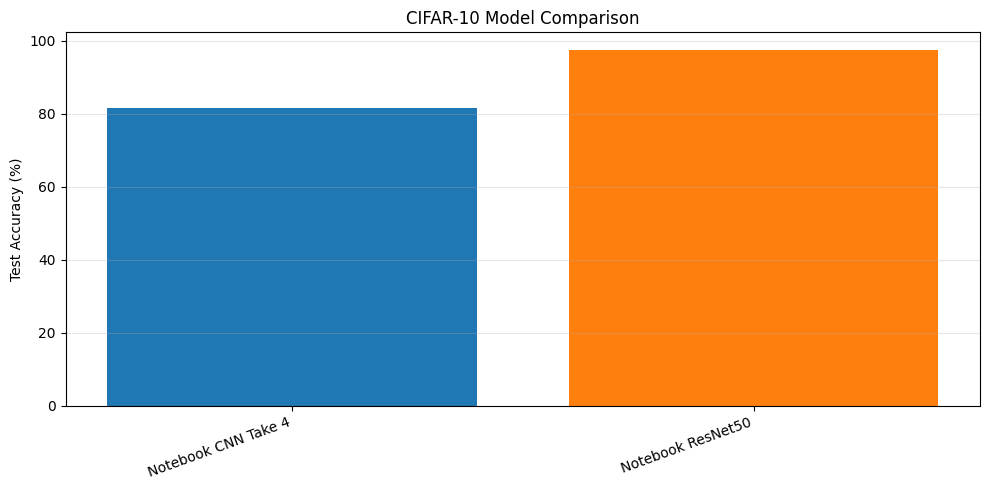

In [ ]:
if not comparison_df.empty:
    plt.figure(figsize=(10, 5))
    plt.bar(comparison_df["experiment"], comparison_df["test_accuracy_pct"], color=["tab:blue", "tab:orange", "tab:green", "tab:red"][: len(comparison_df)])
    plt.ylabel("Test Accuracy (%)")
    plt.title("CIFAR-10 Model Comparison")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [ ]:
if cnn_take4_summary is not None:
    print("CNN Take 4 curves:", cnn_take4_summary["curves_path"])
    print("CNN Take 4 confusion matrix:", cnn_take4_summary["confusion_matrix_path"])

if resnet50_summary is not None:
    print("ResNet50 curves:", resnet50_summary["curves_path"])
    print("ResNet50 confusion matrix:", resnet50_summary["confusion_matrix_path"])


CNN Take 4 curves: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_cnn_take4_20260429_183907/cnn_take4_training_curves.png
CNN Take 4 confusion matrix: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_cnn_take4_20260429_183907/cnn_take4_confusion_matrix.png
ResNet50 curves: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_resnet50_20260429_185255/resnet50_training_curves.png
ResNet50 confusion matrix: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_resnet50_20260429_185255/resnet50_confusion_matrix.png


### Displaying Evaluation Charts


--- CNN Take 4 Charts ---
Displaying CNN Take 4 Training Curves from: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_cnn_take4_20260429_183907/cnn_take4_training_curves.png


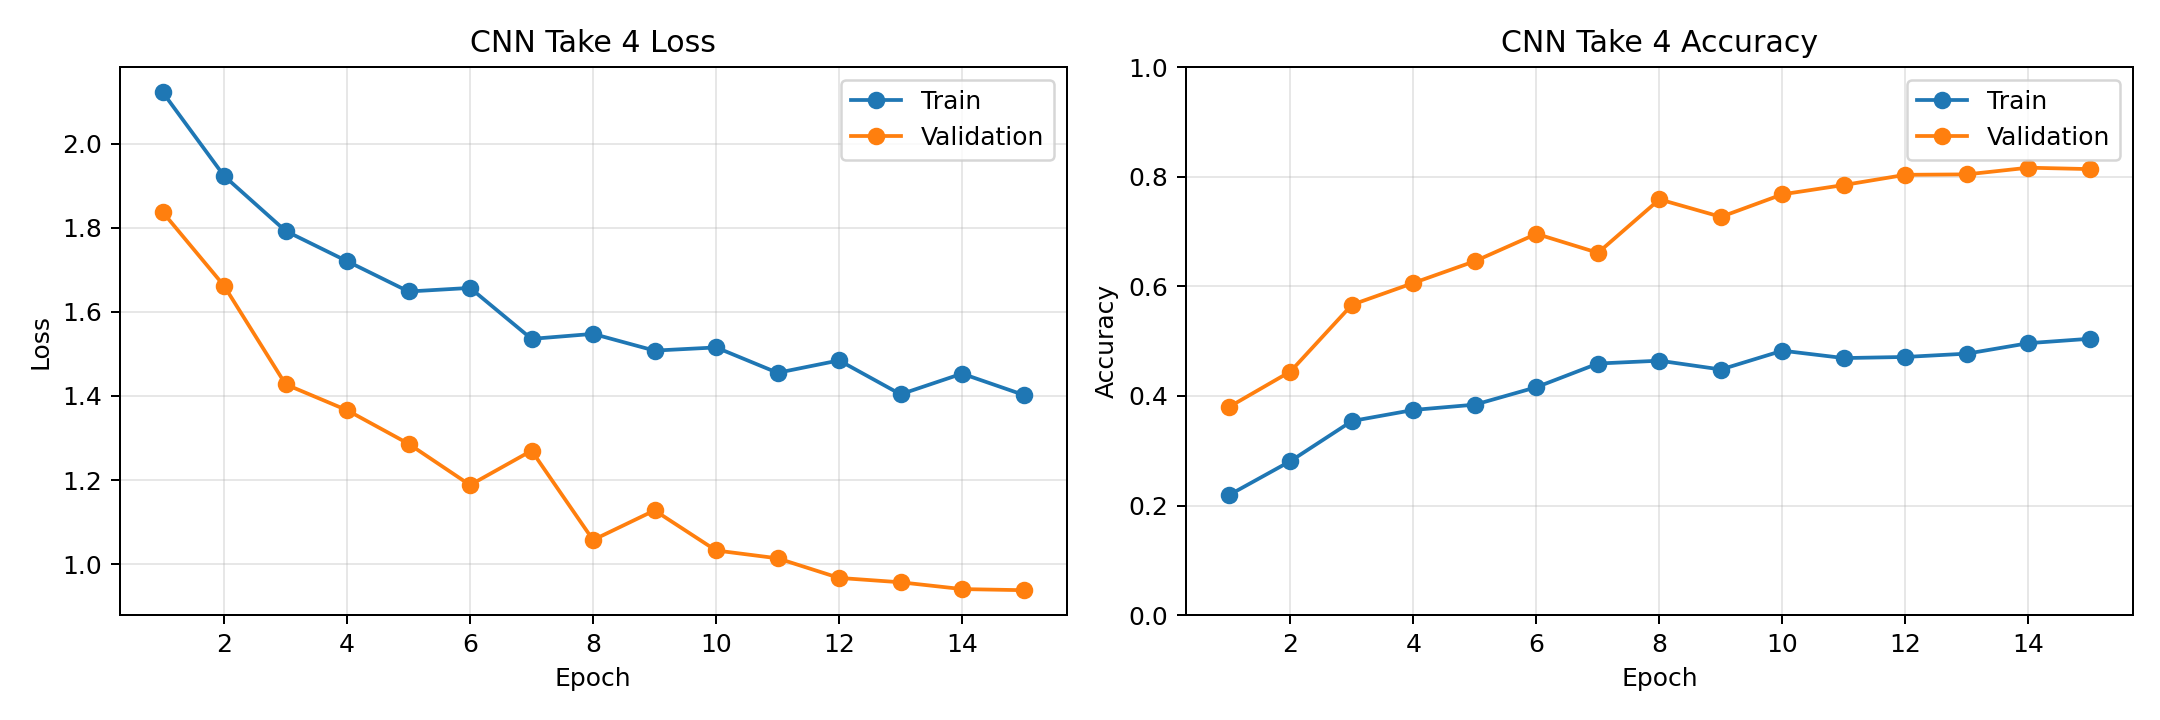

Displaying CNN Take 4 Confusion Matrix from: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_cnn_take4_20260429_183907/cnn_take4_confusion_matrix.png


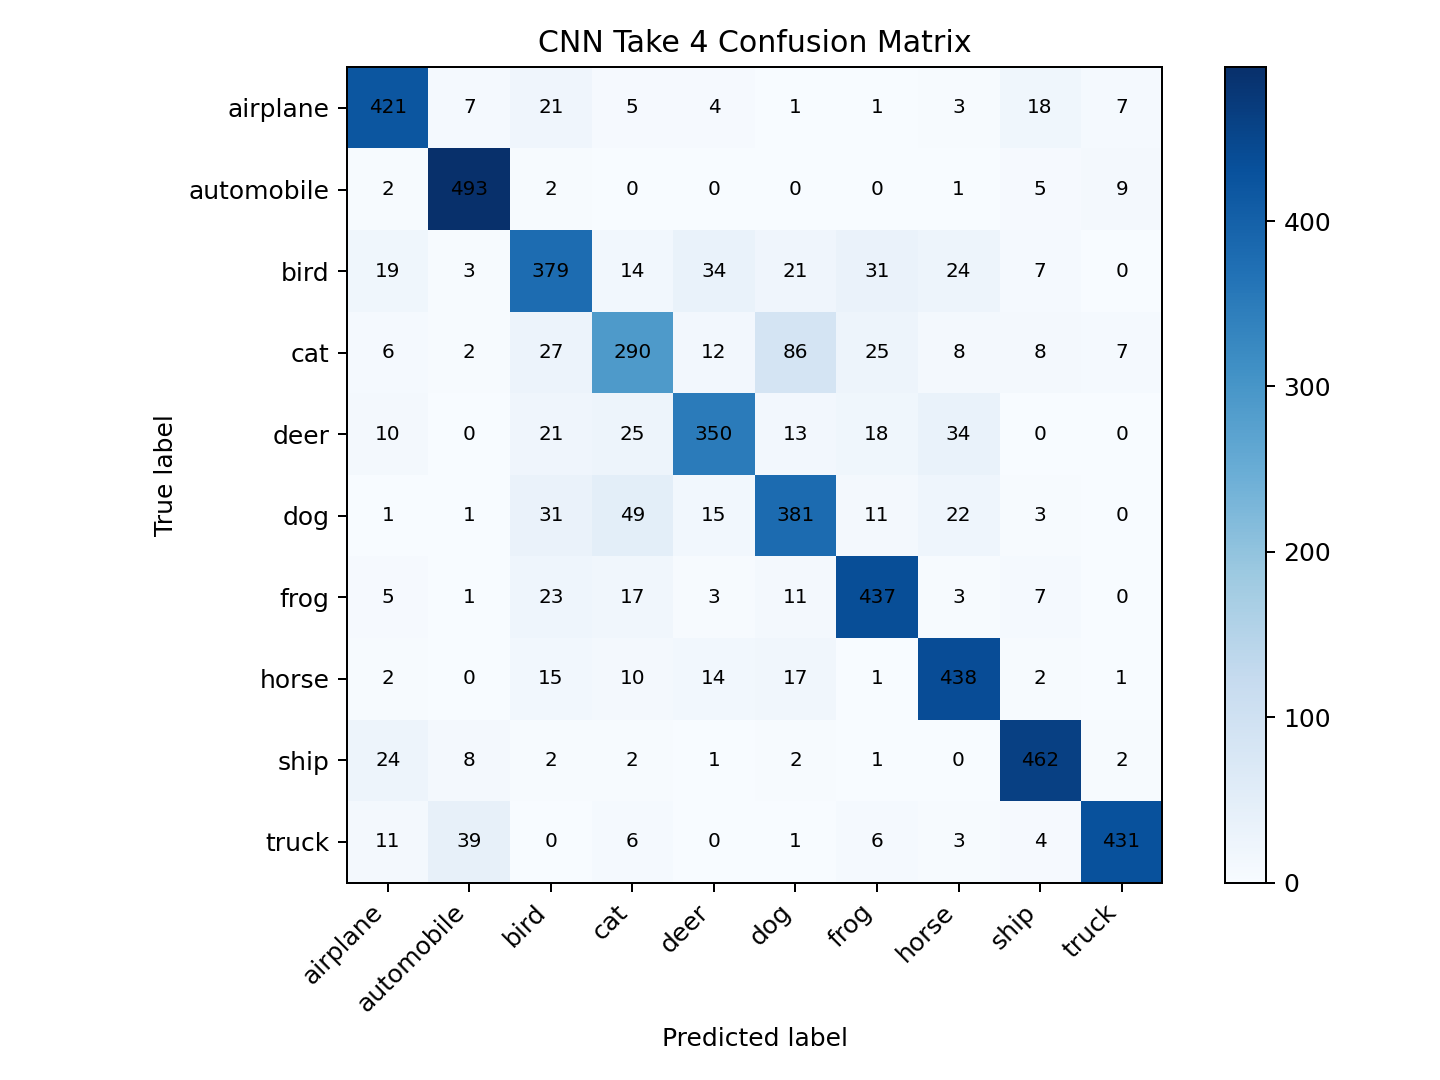


--- ResNet50 Charts ---
Displaying ResNet50 Training Curves from: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_resnet50_20260429_185255/resnet50_training_curves.png


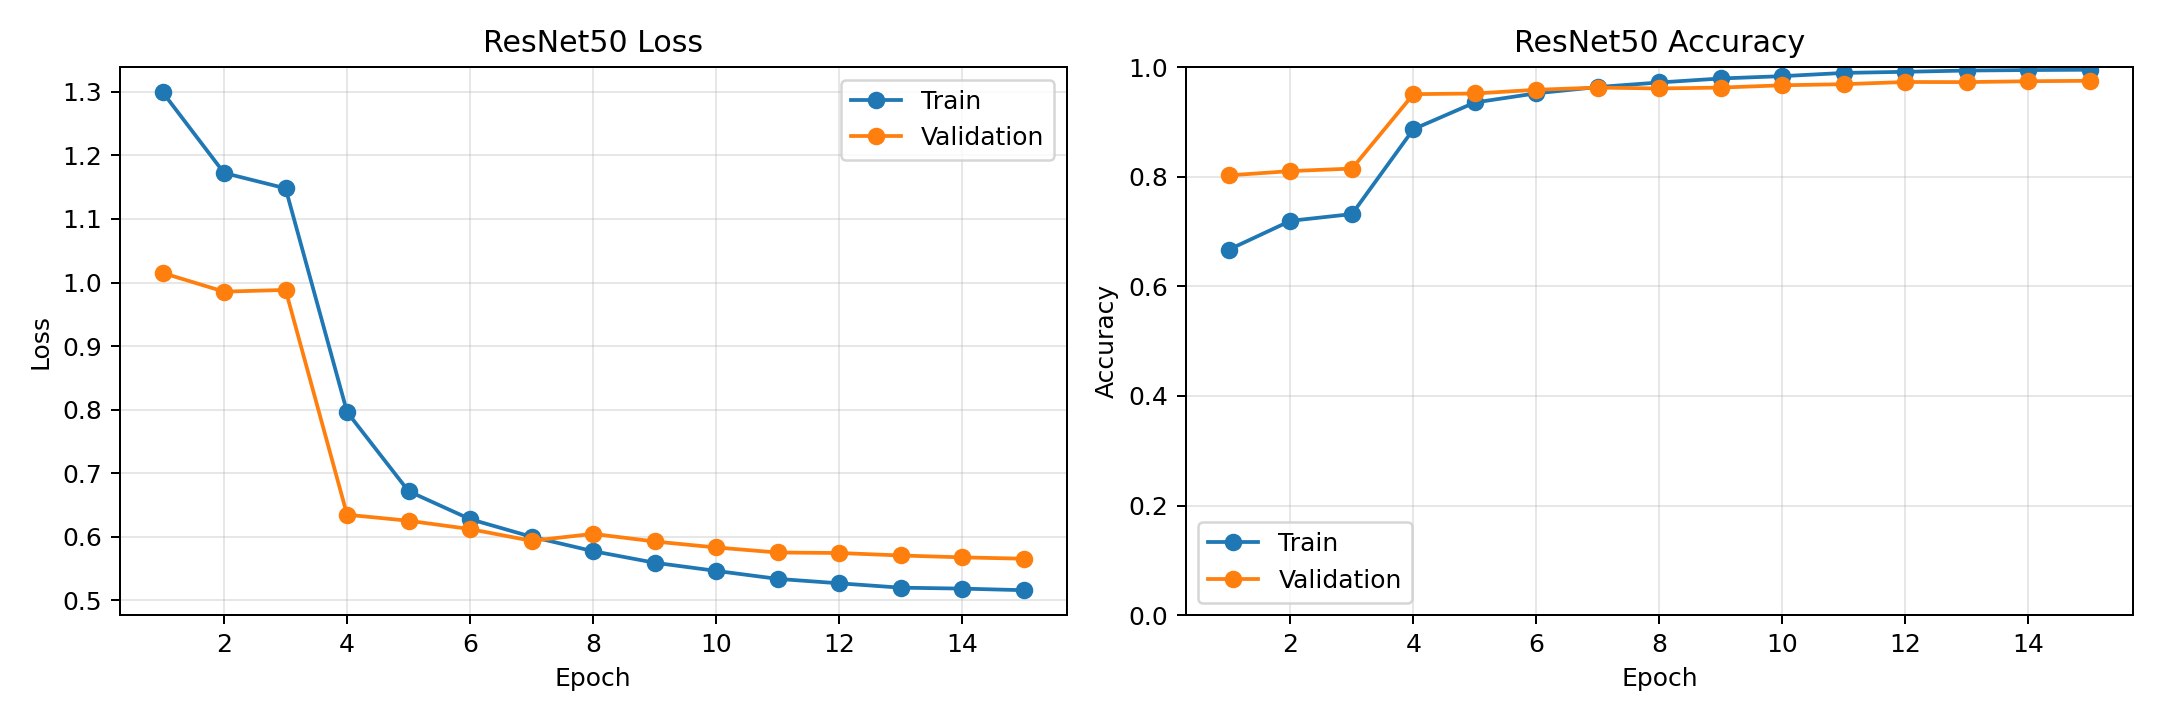

Displaying ResNet50 Confusion Matrix from: /content/drive/MyDrive/Outputs/final_assessment_notebook/final_notebook_resnet50_20260429_185255/resnet50_confusion_matrix.png


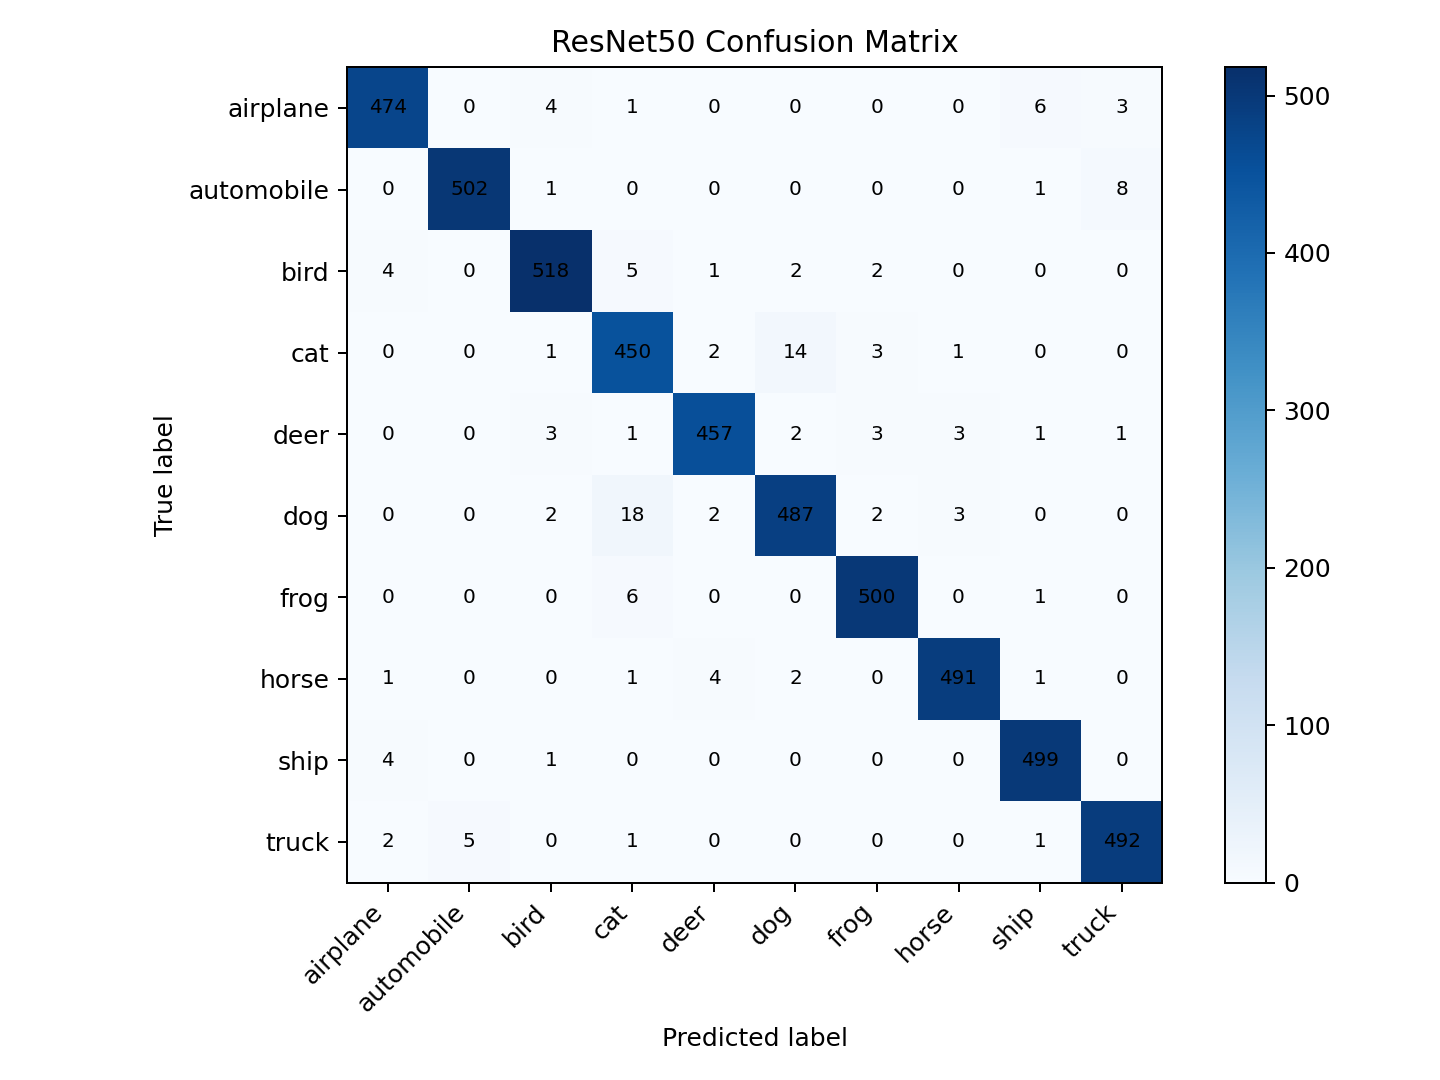

In [ ]:
from IPython.display import Image, display

print("\n--- CNN Take 4 Charts ---")
if cnn_take4_summary is not None:
    print(f"Displaying CNN Take 4 Training Curves from: {cnn_take4_summary['curves_path']}")
    display(Image(filename=cnn_take4_summary['curves_path']))
    print(f"Displaying CNN Take 4 Confusion Matrix from: {cnn_take4_summary['confusion_matrix_path']}")
    display(Image(filename=cnn_take4_summary['confusion_matrix_path']))
else:
    print("CNN Take 4 summary not available. Skipping chart display.")

print("\n--- ResNet50 Charts ---")
if resnet50_summary is not None:
    print(f"Displaying ResNet50 Training Curves from: {resnet50_summary['curves_path']}")
    display(Image(filename=resnet50_summary['curves_path']))
    print(f"Displaying ResNet50 Confusion Matrix from: {resnet50_summary['confusion_matrix_path']}")
    display(Image(filename=resnet50_summary['confusion_matrix_path']))
else:
    print("ResNet50 summary not available. Skipping chart display.")

## Final Notes

This notebook is designed to be the final assessed notebook that accompanies the report. Its section structure matches the written report, and it includes both the scratch-CNN and transfer-learning pipelines in one place.

If you need to rerun only one model, set one of these flags to `False` before running the notebook:

- `RUN_CNN_TAKE4`
- `RUN_RESNET50`
